In [52]:
from matplotlib import pyplot as plt
import numpy as np
from dataclasses import dataclass

@dataclass
class TestResult:
    model_name: str
    f1_oa: float

type ResultsByDataset = dict[str, list[TestResult]]

in_domain_results: ResultsByDataset = {
    "xBD": [
        TestResult("Baseline", 78.12),
        TestResult("AGB", 79.03),
        TestResult("ALIGN \n+ AGB", 79.07),
        TestResult("FOCAL \n+ ALIGN \n+ AGB", 79.16),
    ],
    "Pakistan Flooding": [
        TestResult("Baseline", 80.51),
        TestResult("ALIGN", 80.88),
        TestResult("FOCAL", 80.78),
        TestResult("FOCAL \n+ AGB", 81.33),
    ],
    "Earthquake Turkey": [
        TestResult("Baseline", 48.18),
        TestResult("AGB", 53.20),
        TestResult("FOCAL \n+ AGB", 51.81),
        TestResult("FOCAL \n+ ALIGN \n+ AGBD", 52.60),
    ]
}

cross_domain_results: ResultsByDataset = {
    "Pakistan Flooding": [
        TestResult("Baseline", 29.56),
        TestResult("FOCAL", 48.57),
        TestResult("FOCAL \n+ AGB", 56.60),
        TestResult("ALIGN \n+ AGB", 47.93),
    ],
    "Hurricane Ida": [
        TestResult("Baseline", 40.67),
        TestResult("AGB", 43.76),
        TestResult("ALIGN", 44.24),
        TestResult("ALIGN \n+ AGB", 46.53),
    ],
    "Earthquake Turkey": [
        TestResult("Baseline", 25.23),
        TestResult("AGB", 25.81),
        TestResult("FOCAL \n+ AGB", 27.11),
        TestResult("ALIGN \n+ AGB", 26.54),
    ],
}

def plot_results(R: ResultsByDataset):
    num_rows = 1
    num_cols = 3
    plt.figure(figsize=(6 * num_cols, 4 * num_rows), dpi=200)

    for dataset_idx, (dataset_name, results) in enumerate(R.items(), 1):
        plt.subplot(num_rows, num_cols, dataset_idx)
        plt.title(dataset_name, fontweight="bold")
        model_names = [tr.model_name for tr in results]
        scores = [tr.f1_oa for tr in results]
        plt.bar(model_names, scores, width=0.60, color=["tab:orange", "tab:green","tab:green","tab:green"])
        ymin = min(scores) - min(scores)/20
        ymax = max(scores) + max(scores)/20 + 1
        range = max(scores) - min(scores)
        plt.ylim([ymin, ymax])
        plt.ylabel(r"Overall $F_{1}$ Score (%)", fontweight="bold")
        for i, res in enumerate(results):
            plt.text(i, res.f1_oa + range / 20, f"{res.f1_oa}%", ha="center")
    plt.show()




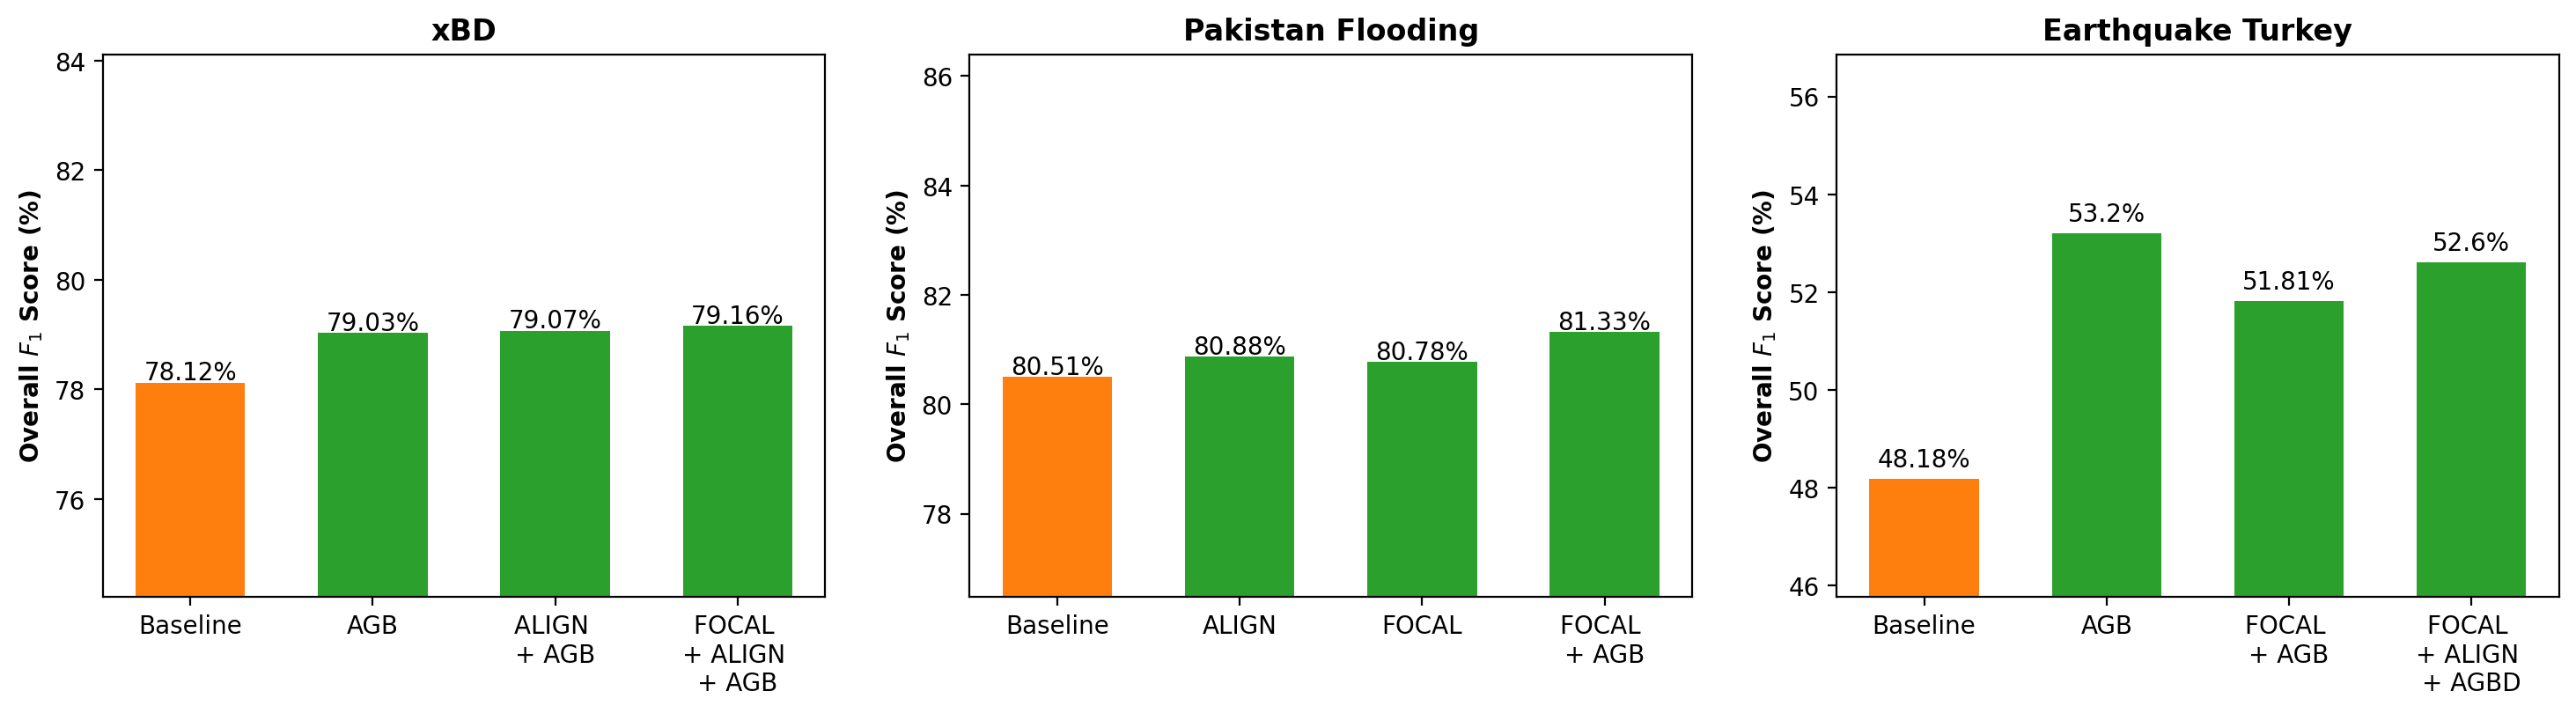

In [53]:
plot_results(in_domain_results)

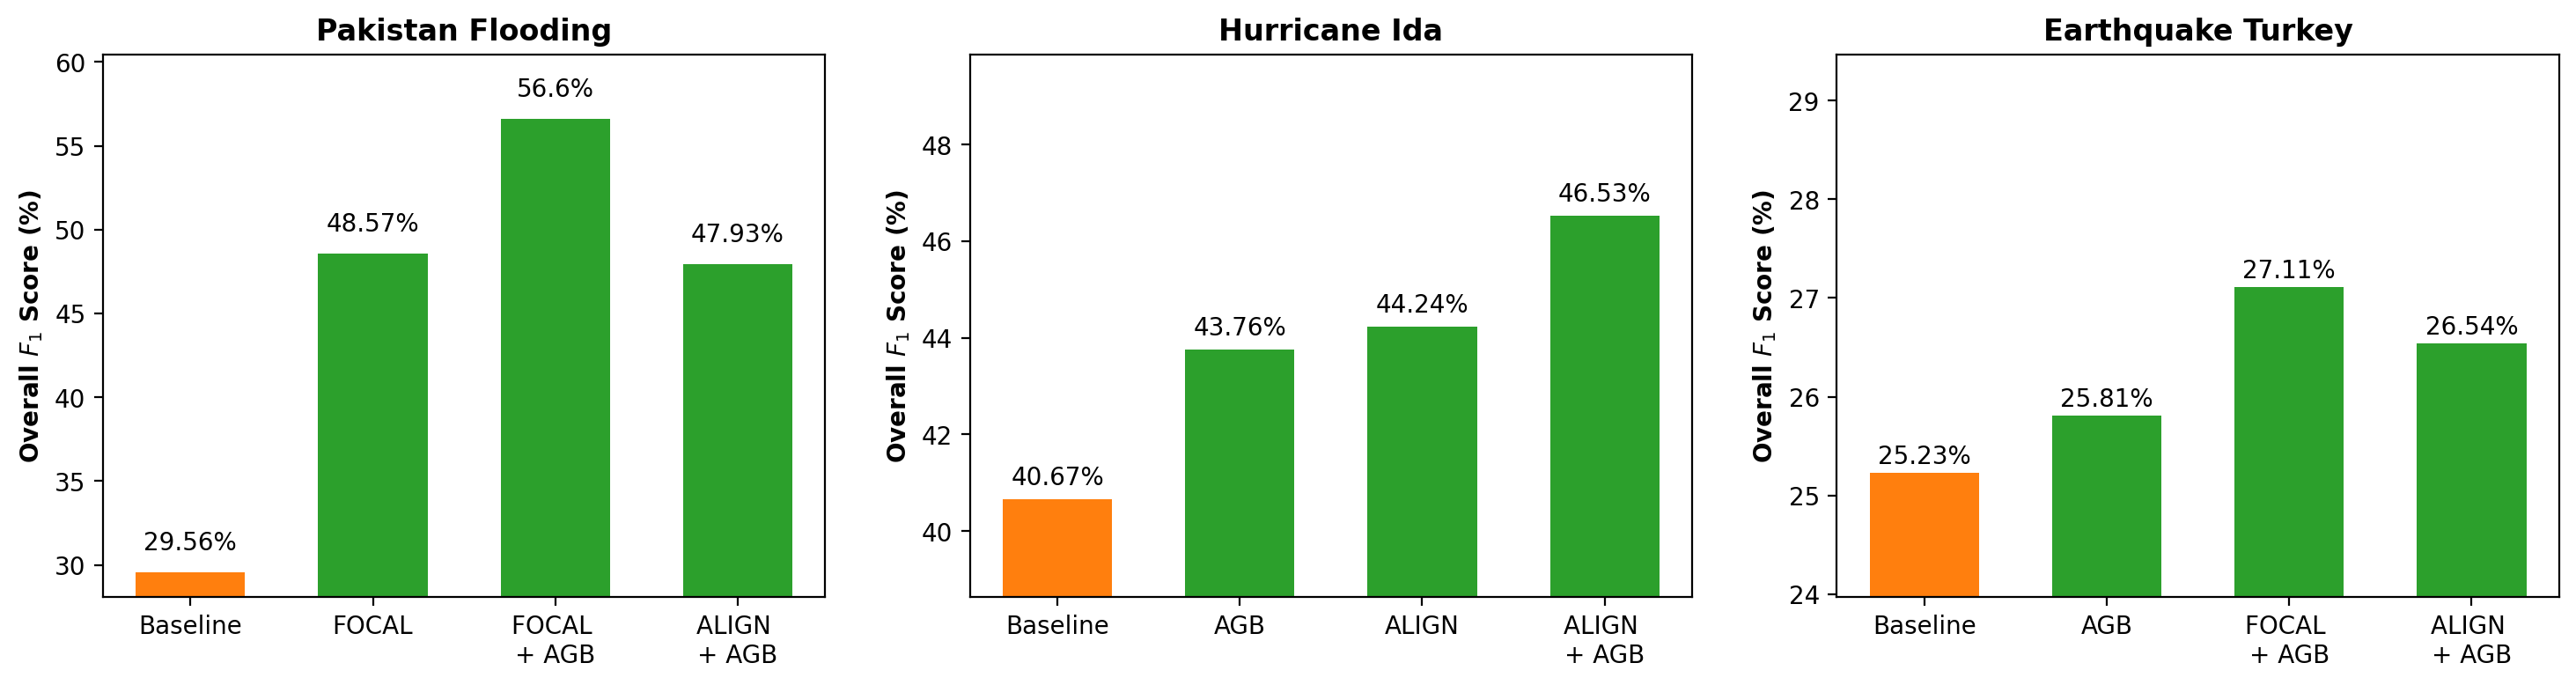

In [54]:
plot_results(cross_domain_results)